In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv("employee_health_dataset_1000.csv")

print(df.head())
print(df.shape)
print(df.dtypes)

   Age  Gender    Job Role  Work Experience  Working Hours  Overtime Hours  \
0   46    Male  Supervisor              8.7             11               1   
1   32    Male     Ironing             15.7              8               2   
2   25    Male   Packaging              9.8              9               3   
3   38  Female   Packaging             10.2              8               0   
4   36    Male   Packaging              4.5             11               2   

   Workload Level  Stress Level  Anxiety Level  Job Satisfaction  \
0             2.0           3.0              3               3.0   
1             4.0           3.0              4               1.0   
2             3.0           4.0              3               3.0   
3             3.0           4.0              3               3.0   
4             4.0           4.0              2               3.0   

   Sleep Duration  Physical Activity  Break Frequency  Fatigue Level  \
0             5.5                  3              

In [48]:
print(df.isnull().sum())

Age                   0
Gender                0
Job Role              0
Work Experience       0
Working Hours         0
Overtime Hours        0
Workload Level       47
Stress Level         42
Anxiety Level         0
Job Satisfaction     59
Sleep Duration       48
Physical Activity     0
Break Frequency       0
Fatigue Level         0
Safety Condition      0
Noise Level           0
Temperature           0
Health Risk           0
dtype: int64


In [49]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [50]:
le = LabelEncoder()
df["Health Risk"] = le.fit_transform(df["Health Risk"])

print(df["Health Risk"].unique())

[1 0]


In [51]:
X = df.drop("Health Risk", axis=1)
y = df["Health Risk"]

In [52]:
X = pd.get_dummies(X, columns=["Gender", "Job Role", "Safety Condition"], drop_first=True)

print(X.dtypes)

Age                            int64
Work Experience              float64
Working Hours                  int64
Overtime Hours                 int64
Workload Level               float64
Stress Level                 float64
Anxiety Level                  int64
Job Satisfaction             float64
Sleep Duration               float64
Physical Activity              int64
Break Frequency                int64
Fatigue Level                  int64
Noise Level                  float64
Temperature                  float64
Gender_Male                     bool
Job Role_Ironing                bool
Job Role_Packaging              bool
Job Role_Sewing Operator        bool
Job Role_Supervisor             bool
Safety Condition_Moderate       bool
Safety Condition_Poor           bool
dtype: object


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [56]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)


Decision Tree
Accuracy: 0.635
Precision: 0.6850393700787402
Recall: 0.725
F1 Score: 0.7044534412955465

Random Forest
Accuracy: 0.635
Precision: 0.6516129032258065
Recall: 0.8416666666666667
F1 Score: 0.7345454545454545

Gradient Boosting
Accuracy: 0.595
Precision: 0.6258064516129033
Recall: 0.8083333333333333
F1 Score: 0.7054545454545454

XGBoost
Accuracy: 0.615
Precision: 0.6462585034013606
Recall: 0.7916666666666666
F1 Score: 0.7116104868913857


In [57]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print(results_df)

               Model  Accuracy  Precision    Recall  F1 Score
0      Decision Tree     0.635   0.685039  0.725000  0.704453
1      Random Forest     0.635   0.651613  0.841667  0.734545
2  Gradient Boosting     0.595   0.625806  0.808333  0.705455
3            XGBoost     0.615   0.646259  0.791667  0.711610


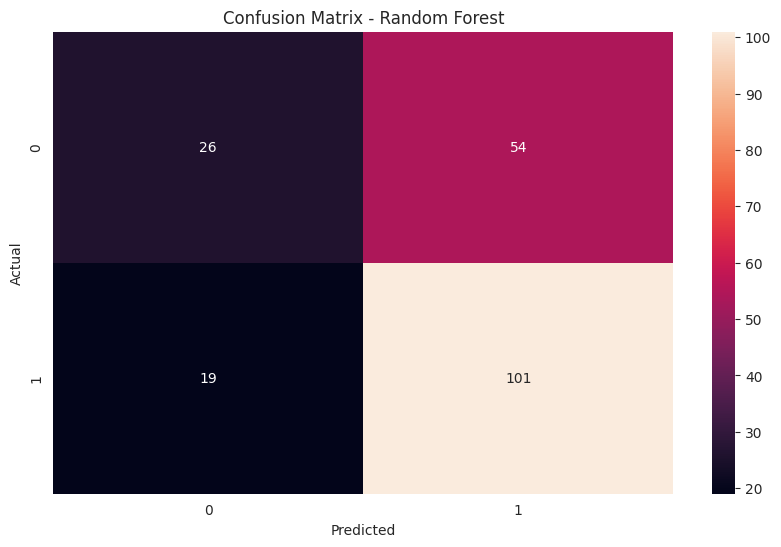

In [58]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
# Form dataset (Displaying the size of the dataframe)
print("Shape:", df.shape)

# Information about data types and the presence of gaps
print("\n--- Data Info ---")
df.info()

# Checking the first lines
print("\n--- First 5 rows ---")
print(df.head())

Shape: (1000, 18)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Gender             1000 non-null   object 
 2   Job Role           1000 non-null   object 
 3   Work Experience    1000 non-null   float64
 4   Working Hours      1000 non-null   int64  
 5   Overtime Hours     1000 non-null   int64  
 6   Workload Level     1000 non-null   float64
 7   Stress Level       1000 non-null   float64
 8   Anxiety Level      1000 non-null   int64  
 9   Job Satisfaction   1000 non-null   float64
 10  Sleep Duration     1000 non-null   float64
 11  Physical Activity  1000 non-null   int64  
 12  Break Frequency    1000 non-null   int64  
 13  Fatigue Level      1000 non-null   int64  
 14  Safety Condition   1000 non-null   object 
 15  Noise Level        1000 non-null   f

In [66]:
df. describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,36.5070,10.960478,18.0,27.0,37.0,46.0,54.0
Work Experience,1000.0,10.1506,5.565847,0.5,5.3,10.1,14.9,20.0
Working Hours,1000.0,9.5280,1.124491,8.0,9.0,9.0,10.0,12.0
Overtime Hours,1000.0,2.0270,1.417844,0.0,1.0,2.0,3.0,4.0
Workload Level,1000.0,2.9950,1.086349,1.0,2.0,3.0,4.0,5.0
Stress Level,1000.0,2.9680,1.069636,1.0,2.0,3.0,4.0,5.0
Anxiety Level,1000.0,2.9450,1.083120,1.0,2.0,3.0,4.0,5.0
Job Satisfaction,1000.0,2.9690,1.021314,1.0,2.0,3.0,4.0,5.0
Sleep Duration,1000.0,6.5140,1.218782,2.8,5.7,6.5,7.3,10.6
Physical Activity,1000.0,3.0500,1.111186,1.0,2.0,3.0,4.0,5.0


In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Training Decision Tree...")

dt = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec = precision_score(y_test, y_pred_dt)
rec = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print(f"\nAccuracy: {acc_dt:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall: {rec:.2%}")
print(f"F1 Score: {f1:.2%}")

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_dt))

Training Decision Tree...

Accuracy: 62.50%
Precision: 67.44%
Recall: 72.50%
F1 Score: 69.88%

Detailed Report:

              precision    recall  f1-score   support

           0       0.54      0.47      0.50        80
           1       0.67      0.72      0.70       120

    accuracy                           0.62       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.62      0.62      0.62       200



In [75]:
print("\nTraining Random Forest...")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_rf))


Training Random Forest...

Random Forest Results:
Accuracy: 0.635
Precision: 0.6516129032258065
Recall: 0.8416666666666667
F1 Score: 0.7345454545454545

Detailed Report:

              precision    recall  f1-score   support

           0       0.58      0.33      0.42        80
           1       0.65      0.84      0.73       120

    accuracy                           0.64       200
   macro avg       0.61      0.58      0.58       200
weighted avg       0.62      0.64      0.61       200



In [76]:
print("\nTraining Gradient Boosting...")

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("\nGradient Boosting Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_gb))


Training Gradient Boosting...

Gradient Boosting Results:
Accuracy: 0.595
Precision: 0.6258064516129033
Recall: 0.8083333333333333
F1 Score: 0.7054545454545454

Detailed Report:

              precision    recall  f1-score   support

           0       0.49      0.28      0.35        80
           1       0.63      0.81      0.71       120

    accuracy                           0.59       200
   macro avg       0.56      0.54      0.53       200
weighted avg       0.57      0.59      0.56       200



In [77]:
print("\nTraining XGBoost...")

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_xgb))


Training XGBoost...

XGBoost Results:
Accuracy: 0.615
Precision: 0.6462585034013606
Recall: 0.7916666666666666
F1 Score: 0.7116104868913857

Detailed Report:

              precision    recall  f1-score   support

           0       0.53      0.35      0.42        80
           1       0.65      0.79      0.71       120

    accuracy                           0.61       200
   macro avg       0.59      0.57      0.57       200
weighted avg       0.60      0.61      0.60       200



In [78]:
# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

             Feature  Importance
13       Temperature    0.099468
12       Noise Level    0.097002
8     Sleep Duration    0.090365
1    Work Experience    0.088982
0                Age    0.084931
5       Stress Level    0.074942
11     Fatigue Level    0.072287
4     Workload Level    0.050957
10   Break Frequency    0.043727
7   Job Satisfaction    0.042410


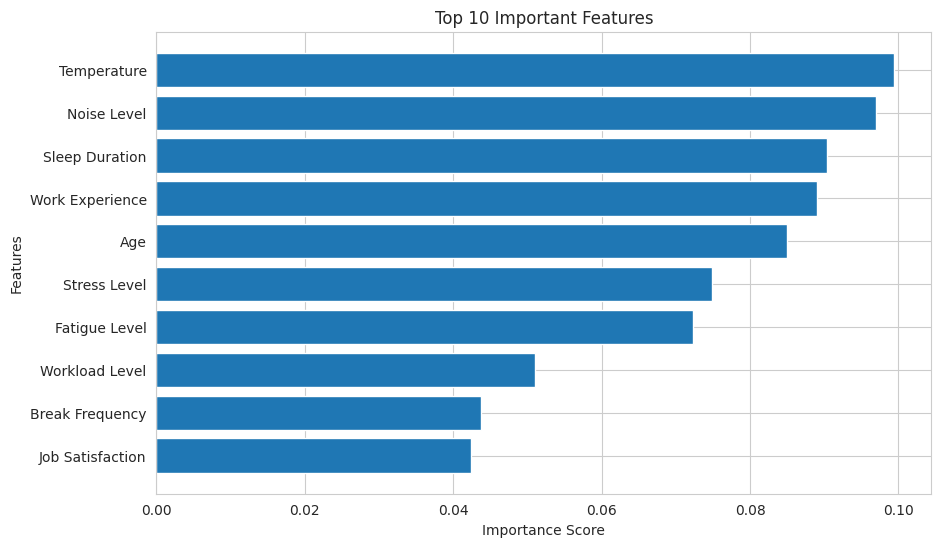

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:10], feature_importance["Importance"][:10])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [80]:
import pandas as pd

# Train all models (if not already)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Create empty dataframe
feature_table = pd.DataFrame()
feature_table["Feature"] = X.columns

# Add importance from each model
feature_table["Decision Tree"] = dt.feature_importances_
feature_table["Random Forest"] = rf.feature_importances_
feature_table["Gradient Boosting"] = gb.feature_importances_
feature_table["XGBoost"] = xgb.feature_importances_

# Sort by Random Forest (best model)
feature_table = feature_table.sort_values(by="Random Forest", ascending=False)

print(feature_table.head(10))

             Feature  Decision Tree  Random Forest  Gradient Boosting  \
13       Temperature       0.129079       0.099468           0.137242   
12       Noise Level       0.065463       0.097002           0.091333   
8     Sleep Duration       0.071833       0.090365           0.089342   
1    Work Experience       0.094113       0.088982           0.078905   
0                Age       0.077791       0.084931           0.059470   
5       Stress Level       0.104135       0.074942           0.139894   
11     Fatigue Level       0.083894       0.072287           0.116724   
4     Workload Level       0.042110       0.050957           0.070266   
10   Break Frequency       0.037408       0.043727           0.037804   
7   Job Satisfaction       0.027939       0.042410           0.058157   

     XGBoost  
13  0.045041  
12  0.035811  
8   0.037895  
1   0.034683  
0   0.035583  
5   0.102905  
11  0.081504  
4   0.053044  
10  0.042807  
7   0.055433  


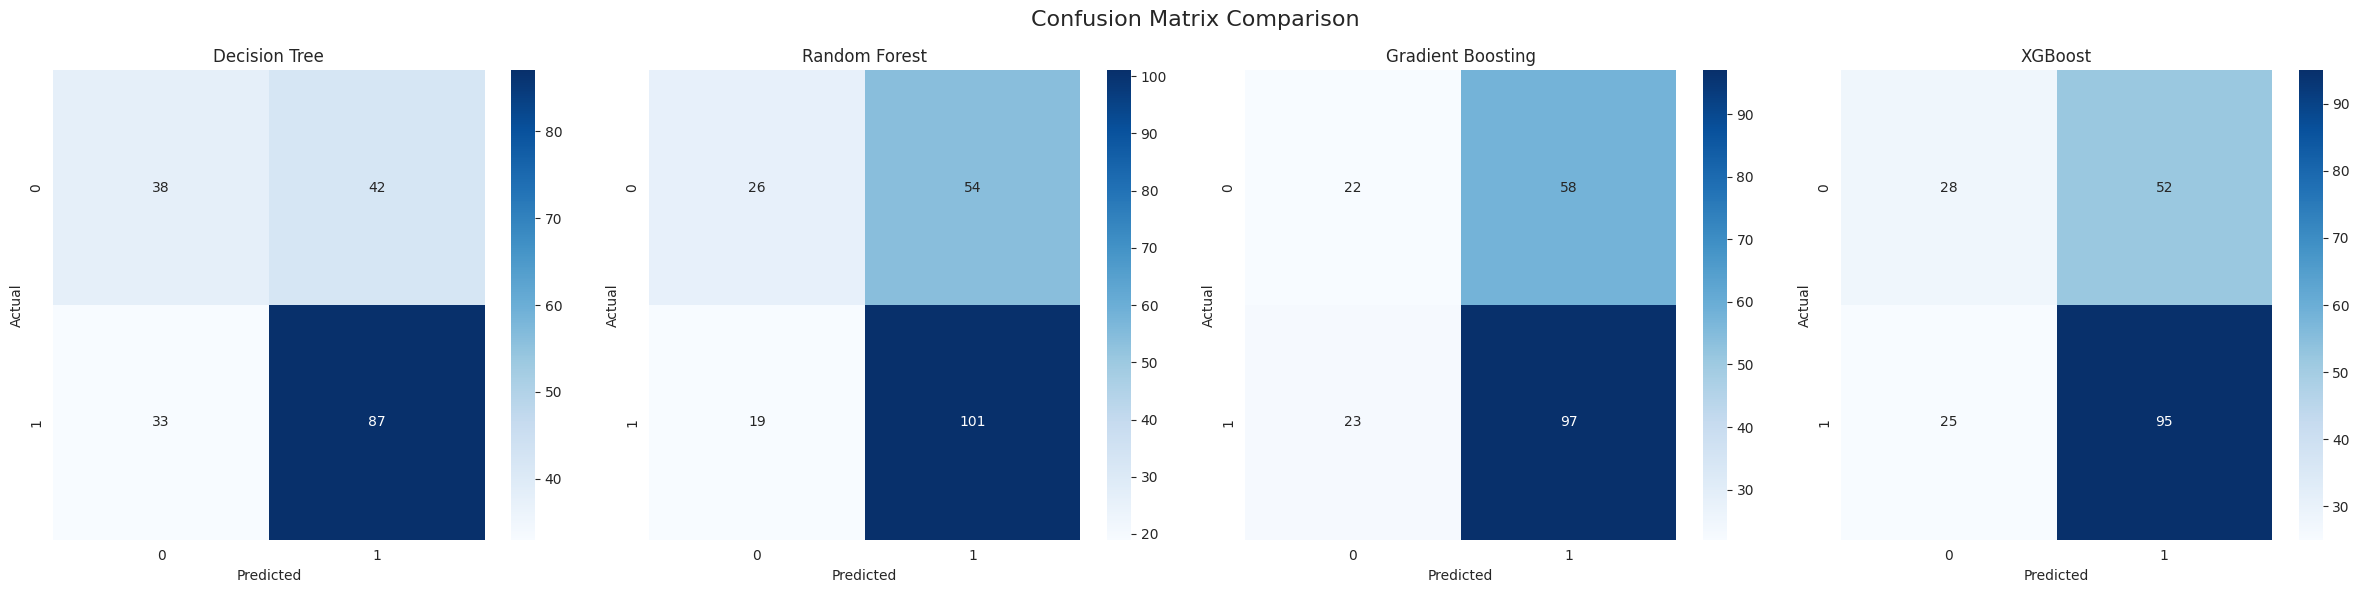

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models_list = [
    ("Decision Tree", dt),
    ("Random Forest", rf),
    ("Gradient Boosting", gb),
    ("XGBoost", xgb)
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = np.array(axes).flatten()

for i, (name, model) in enumerate(models_list):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=16)
plt.tight_layout()
plt.show()

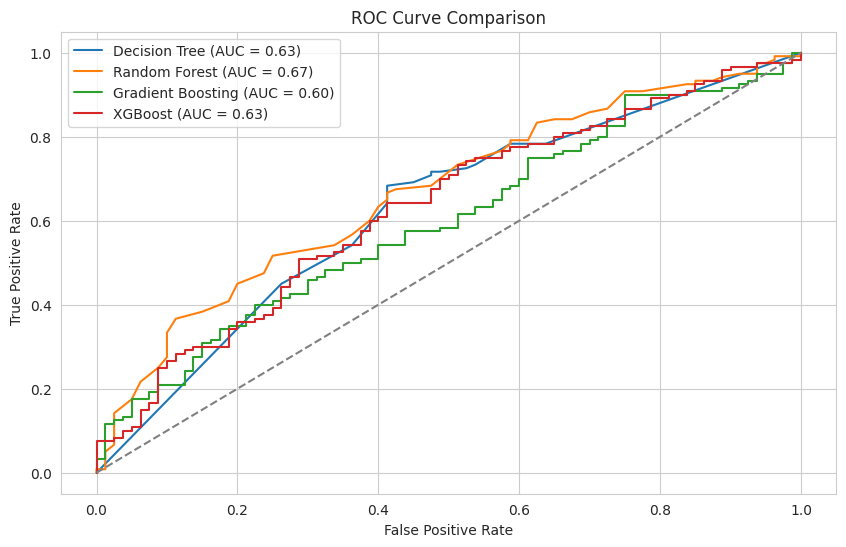

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10,6))

for name, model in models_list:
    # Get probability scores
    y_prob = model.predict_proba(X_test)[:,1]

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()